# Modèle pilote de l'évolution de la coopération 

**Guillaume Benharrats** - septembre 2026

---

**Résumé.** Pourquoi des individus aident-ils des inconnus qu'ils ne reverront jamais, alors que la sélection naturelle devrait favoriser ceux qui profitent de l'aide sans la rendre ? Une réponse pourrait être la réciprocité indirecte: aider construit une réputation, et ceux qui ont une bonne réputation sont aidés en retour (Nowak & Sigmund, 1998 ; Nowak, 2006). Ce notebook propose un modèle multi-agents simple pour reproduire l'effondrement de la coopération en l'absence de réputation, vérifier par simulation la règle de Nowak selon laquelle la coopération ne tient que si la probabilité de connaître la réputation d'autrui, q, dépasse le rapport coût/bénéfice *c/b*, et explorer le rôle d'un tiers de confiance (registre public) dans une société trop grande pour que les commérages suffisent. Le résultat principal est un effet de seuil : une amélioration modeste de l'information, si elle fait franchir le seuil *c/b*, fait passer la population d'un état presque sans coopération à un état presque entièrement coopératif. Avec les paramètres retenus, un registre coûteux fait baisser le bien-être dans une petite société mais devient très rentable au-delà d'environ 80 personnes.

## 1. Contexte et question

Dans le jeu du don, un donneur peut payer un coût c pour qu'un receveur gagne un bénéfice b > c. Dans une population où les partenaires sont tirés au hasard, un déserteur reçoit autant d'aide qu'un coopérateur sans en payer le coût. La sélection élimine la coopération, alors même qu'une population de coopérateurs serait plus prospère.

La réciprocité indirecte résout ce problème si l'information circule, les individus aident ceux qui ont une bonne réputation et refusent d'aider ceux qui ont une mauvaise réputation. Mais dans une grande société anonyme, on connaît rarement la réputation d'un inconnu. D'où la question de ce petit projet :

> **Quelle quantité d'information faut-il pour que la coopération tienne, et un tiers de confiance peut-il la fournir quand les commérages ne suffisent plus ?**


## 2. Le modèle

**Population.** `N = 100` individus, chacun porteur d'une stratégie transmise à ses descendants (génétiquement ou culturellement) :

| Stratégie | Comportement |
|---|---|
| **Coopérateur inconditionnel** (ALLC) | aide toujours |
| **Déserteur** (ALLD) | n'aide jamais |
| **Discriminant** (DISC) | aide, sauf s'il sait que le receveur a une mauvaise réputation |

**Interactions.** Chaque génération comporte `R = 10` tours. À chaque tour, chaque individu est donneur une fois, face à un receveur tiré au hasard. Un donneur **connaît la réputation** du receveur avec une probabilité `q` ; s'il ne la connaît pas, le discriminant aide par défaut. Avec une petite probabilité `e`, un donneur qui voulait aider se trompe et n'aide pas (erreur d'exécution).

**Réputation.** Chaque individu naît avec une bonne réputation (*présomption de bonne foi*). Après chaque action, sa réputation est mise à jour selon la règle dite du *standing* :
- aider → bonne réputation ;
- refuser d'aider quelqu'un de **bonne** réputation → mauvaise réputation ;
- refuser d'aider quelqu'un de **mauvaise** réputation → refus **justifié**, la réputation reste bonne.

Cette dernière règle évite un défaut connu du modèle le plus simple (*image scoring*), où punir un tricheur abîme sa propre réputation.

**Sélection.** À la fin de chaque génération, la génération suivante est tirée au sort : chaque individu a une chance de laisser un descendant proportionnelle à `exp(s × gain)`, où `s` mesure l'intensité de la sélection. Avec une probabilité `mu`, un descendant mute vers une stratégie tirée au hasard.

=> 100 personnes vivent 10 journées où elles s'aident ou non selon les réputations ; les plus riches ont plus d'enfants ; on répète 300 fois et on regarde quelle stratégie finit par dominer le village.

Simplification : Les trois stratégies ne sont pas présentes dans tous les résultats. Le résultat 1 oppose coopérateurs inconditionnels et déserteurs ; les résultats 2 et 3 opposent seulement discriminants et déserteurs. En effet, dans une population de discriminants où tout le monde a une bonne réputation, les coopérateurs inconditionnels se comportent exactement comme les discriminants et peuvent donc se répandre par pur hasard (dérive neutre) ; comme ils aident aussi les déserteurs démasqués, ils finissent par les nourrir et leur ouvrir la voie. Dans des essais préliminaires, ce mécanisme faisait s'effondrer la coopération même avec une information presque parfaite, ce qui masquait le rôle de q. Les retirer permet de tester proprement la règle q > c/b, qui compare justement discriminants et déserteurs ; étudier leur effet serait un prolongement naturel.


In [1]:
import numpy as np                           # numpy : calculs rapides sur des tableaux de nombres
import matplotlib.pyplot as plt              # matplotlib : pour dessiner les graphiques
from matplotlib.colors import ListedColormap # outil pour choisir nos propres couleurs dans les images

rng = np.random.default_rng(2026)            # crée un « tireur au sort »
                                             # 2026 est la « graine » : avec la même graine, le hasard
                                             # donne exactement les mêmes tirages à chaque fois,
                                             # donc les mêmes résultats (simulation reproductible)

ALLC, ALLD, DISC = 0, 1, 2                   # 0 = gentil (aide toujours)
                                             # 1 = profiteur (n'aide jamais)
                                             # 2 = prudent (aide sauf les profiteurs connus)

BLEU, ORANGE, GRIS = "#2F6DB5", "#E8833A", "#8A8A8A"   # codes couleur
                                             # bleu = coopérateurs, orange = profiteurs,
                                             # gris = scénario sans registre (partie 5)

# Les réglages du modèle:
PARAMS = dict(
    N=100,     # 100 habitants dans le village
    b=3.0,     # bénéfice : celui qui est aidé gagne 3
    c=1.0,     # coût : celui qui aide perd 1
    R=10,      # 10 journées (tours) par vie
    G=300,     # 300 générations simulées
    mu=0.01,   # 1 % de chance qu'un enfant change de stratégie (mutation)
    e=0.02,    # 2 % de chance de ne pas aider par erreur
    s=0.3,     # intensité de la sélection : à quel point un gain élevé donne plus d'enfants
)

In [4]:
#La fonction simuler. Elle fait évoluer la population pendant G générations et renvoie, pour chaque génération,_
#la composition de la population, le taux de coopération et le gain moyen. Le paramètre strategies indique quelles stratégies_
#existent dans la population (y compris pour les mutations). Par défaut, strategies=(ALLD, DISC) :_
#seuls les déserteurs et les discriminants sont présents, sans coopérateurs inconditionnels,_
#conformément à la simplification décrite ci-dessus ; c'est le cas des résultats 2 et 3._ 
#Pour le résultat 1, on appelle la fonction avec strategies=(ALLC, ALLD) afin de n'avoir que des coopérateurs inconditionnels_
#et des déserteurs. Le paramètre init fixe la stratégie majoritaire au départ et p_init sa proportion initiale_
#(par défaut, 100 % de discriminants).

def simuler(q, strategies=(ALLD, DISC), init=DISC, p_init=1.0,
            N=100, b=3.0, c=1.0, R=10, G=300, mu=0.01, e=0.02, s=0.3):
    # Cette fonction fait vivre le village pendant G générations.
    # q = probabilité de connaître la réputation de quelqu'un (paramètre étudié)
    # strategies = les stratégies qui existent dans le village (par défaut : profiteurs et prudents)
    # init = la stratégie de départ majoritaire (par défaut : prudent)
    # p_init = part de cette stratégie au départ (1.0 = 100 %)
    # les autres réglages sont ceux de PARAMS (N, b, c, R, G, mu, e, s)

    #PREMIER VILLAGE :
    strategies = np.array(strategies)           # transforme la liste en tableau numpy
    autres = strategies[strategies != init]     # les stratégies autres que celle de départ
    pop = np.where(rng.random(N) < p_init, init, rng.choice(autres, N))
    # pour chacun des N habitants : on tire un nombre entre 0 et 1
    #   - s'il est < p_init → l'habitant reçoit la stratégie de départ
    #   - sinon → il reçoit une des autres stratégies au hasard
    # pop est donc une liste de 100 codes, ex : [2, 2, 1, 2, ...]

    historique, taux_coop, gain_moyen = [], [], []   # carnets vides pour noter les résultats

    #BOUCLE SUR LES GÉNÉRATIONS (300 vies) :
    for g in range(G):
        reputation = np.ones(N, dtype=bool)     # tout le monde naît avec une bonne réputation
                                                # (True = bonne, False = mauvaise)
        gains = np.zeros(N)                     # tout le monde commence avec un gain de 0
        n_coop = 0                              # compteur du nombre d'aides dans cette vie

        #BOUCLE SUR LES JOURNÉES (10 tours) :
        for tour in range(R):

            #1. Chacun croise quelqu'un au hasard
            receveur = rng.integers(0, N - 1, N)        # pour chaque habitant, un numéro entre 0 et 98
            receveur[receveur >= np.arange(N)] += 1     # astuce : on décale d'un cran pour ne jamais
                                                        # tomber sur soi-même (numéros 0 à 99 sauf soi)

            #2. Le donneur connaît-il la réputation de l'autre ?
            connait = rng.random(N) < q                 # True avec une probabilité q, sinon False
            rep_receveur = reputation[receveur]         # la réputation actuelle de chaque receveur

            #3. Chacun décide d'aider ou non, selon sa stratégie
            aide = np.where(pop == ALLC, True,          # le gentil aide toujours
                   np.where(pop == ALLD, False,         # le profiteur n'aide jamais
                            ~connait | rep_receveur))   # le prudent aide si :
                                                        #   il NE connaît PAS la réputation (~ = « non »)
                                                        #   OU (| = « ou ») le receveur a une bonne réputation
            aide &= rng.random(N) >= e                  # 2 % de chance que l'aide échoue par erreur
                                                        # (&= : « et en plus, il ne s'est pas trompé »)

            #4. On paie les coûts et on distribue les bénéfices
            gains[aide] -= c                            # ceux qui aident perdent c = 1
            np.add.at(gains, receveur[aide], b)         # ceux qui sont aidés gagnent b = 3
                                                        # (add.at gère le cas où la même personne
                                                        #  est aidée plusieurs fois dans la journée)

            #5. Le village met à jour les réputations (règle du "standing")
            reputation = aide | ~rep_receveur
            # bonne réputation si : j'ai aidé
            #                  OU   celui que j'ai refusé avait une mauvaise réputation (refus justifié)
            # sinon (j'ai refusé d'aider quelqu'un de bien) → mauvaise réputation

            n_coop += aide.sum()                        # on compte les aides de la journée

        #FIN DE LA VIE : on note les résultats 
        historique.append(pop.copy())                   # la composition du village (pour l'image)
        taux_coop.append(n_coop / (N * R))              # part des rencontres où il y a eu de l'aide
        gain_moyen.append(gains.mean())                 # gain moyen des habitants

        #LA LOTERIE : qui a des enfants ?
        w = np.exp(s * (gains - gains.max()))           # les tickets de chacun
        pop = pop[rng.choice(N, N, p=w / w.sum())]      # 100 tirages : chaque enfant copie
                                                        # la stratégie du parent tiré
        mutants = rng.random(N) < mu                    # 1 % des enfants mutent...
        pop[mutants] = rng.choice(strategies, mutants.sum())  # ...et prennent une stratégie au hasard

    # on renvoie les 3 carnets de résultats, transformés en tableaux
    return np.array(historique), np.array(taux_coop), np.array(gain_moyen)


def afficher_population(ax, historique, valeurs, couleurs, titre):
    # Dessine l'image « une ligne = une génération, une colonne = un habitant »
    ordre = np.sort(historique, axis=1)         # dans chaque génération, on range les habitants
                                                # par stratégie (sinon l'image serait un mélange illisible)
    ax.imshow(ordre, aspect="auto", interpolation="nearest",    # transforme le tableau en image...
              cmap=ListedColormap(couleurs),                     # ...avec nos couleurs...
              vmin=valeurs[0], vmax=valeurs[-1])                 # ...associées aux bons codes de stratégie
    ax.set_xlabel("Individus"); ax.set_ylabel("Génération"); ax.set_title(titre)   # titres des axes

## 3. Résultat 1 — Sans réputation, la coopération s'effondre

On part d'une population composée à 90 % de coopérateurs inconditionnels et à 10 % de déserteurs, sans aucune information sur les réputations.

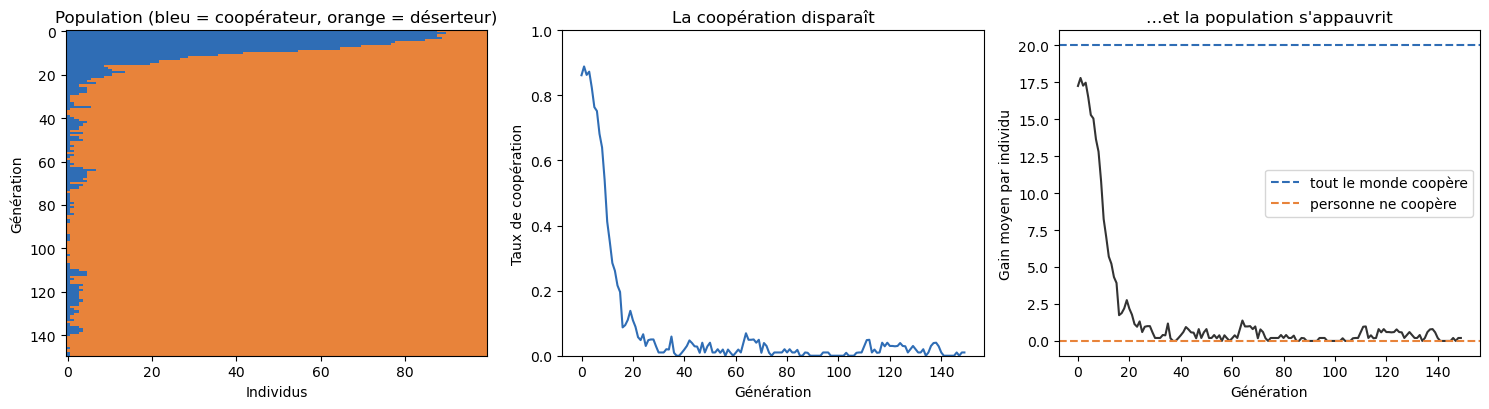

Taux de coopération : 86% au départ, 2% à la fin


In [5]:
#1. ON LANCE LA SIMULATION:
# sélection plus faible (s = 0.03) uniquement ici, pour que la dynamique soit visible
# sur plusieurs générations au lieu de s'effondrer en deux ou trois générations
hist1, coop1, gain1 = simuler(
    q=0.0,                      # personne ne connaît la réputation de personne (pas d'information)
    strategies=(ALLC, ALLD),    # le village ne contient que des gentils et des profiteurs
    init=ALLC, p_init=0.9,      # au départ : 90 % de gentils (donc 10 % de profiteurs)
    s=0.03,                     # sélection faible, pour voir la chute se faire progressivement
    G=150)                      # 150 générations suffisent ici (au lieu de 300)
# La fonction renvoie 3 résultats, rangés dans 3 variables :
#   hist1 = la composition du village à chaque génération (pour l'image)
#   coop1 = le taux de coopération à chaque génération
#   gain1 = le gain moyen à chaque génération

#2. ON PRÉPARE LA FIGURE: 
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
# une figure avec 1 ligne et 3 cases côte à côte : ax[0], ax[1], ax[2]
# figsize = taille de la figure (largeur 15, hauteur 4,2)

#Case 1 (à gauche) : l'image du village 
afficher_population(ax[0], hist1, [ALLC, ALLD], [BLEU, ORANGE],
                    "Population (bleu = coopérateur, orange = déserteur)")
# dessine une ligne par génération, un habitant par colonne
# les gentils (ALLC) en bleu, les profiteurs (ALLD) en orange

#Case 2 (au milieu) : la courbe du taux de coopération
ax[1].plot(coop1, color=BLEU)                       # trace la courbe en bleu
ax[1].set_ylim(0, 1)                                # l'axe vertical va de 0 (0 %) à 1 (100 %)
ax[1].set_xlabel("Génération")                      # nom de l'axe horizontal
ax[1].set_ylabel("Taux de coopération")             # nom de l'axe vertical
ax[1].set_title("La coopération disparaît")         # titre de la case

#Case 3 (à droite) : la courbe du gain moyen
R, b, c = PARAMS["R"], PARAMS["b"], PARAMS["c"]     # on récupère 10 tours, b = 3, c = 1
ax[2].plot(gain1, color="#333333")                  # trace le gain moyen en gris foncé
ax[2].axhline(R * (b - c), ls="--", color=BLEU,     # ligne pointillée bleue à 10 × (3 − 1) = 20 :
              label="tout le monde coopère")        # le gain si TOUT le monde coopère (le maximum)
ax[2].axhline(0, ls="--", color=ORANGE,             # ligne pointillée orange à 0 :
              label="personne ne coopère")          # le gain si PERSONNE ne coopère
ax[2].set_xlabel("Génération")
ax[2].set_ylabel("Gain moyen par individu")
ax[2].set_title("…et la population s'appauvrit")
ax[2].legend()                                      # affiche la légende des deux lignes pointillées

plt.tight_layout()                                  # ajuste les espaces pour que rien ne se chevauche
plt.show()                                          # affiche la figure

#3. ON AFFICHE LE RÉSULTAT EN CHIFFRES:
print(f"Taux de coopération : {coop1[0]:.0%} au départ, {coop1[-50:].mean():.0%} à la fin")
# coop1[0]              = le taux de coopération de la 1re génération
# coop1[-50:].mean()    = la moyenne des 50 dernières générations
#                         (plus fiable qu'une seule génération, qui peut être due au hasard)
# :.0%                  = affiche le nombre en pourcentage sans décimale (0.86 → 86 %)

**Lecture.** Les déserteurs envahissent la population en quelques dizaines de générations. Le gain moyen chute de *R(b − c)* à presque 0 : la sélection naturelle, qui avantage chaque déserteur individuellement, dégrade le résultat collectif. C'est le dilemme du prisonnier à l'échelle de l'évolution, et la raison pour laquelle le théorème fondamental de Fisher ne s'applique pas ici : la sélection dépend de la fréquence des stratégies.

## 4. Résultat 2 — La réputation sauve la coopération… au-delà d'un seuil

On introduit maintenant les **discriminants**. On part d'une population entièrement discriminante et on regarde si elle résiste à l'invasion de déserteurs apparus par mutation. On compare d'abord deux niveaux d'information.

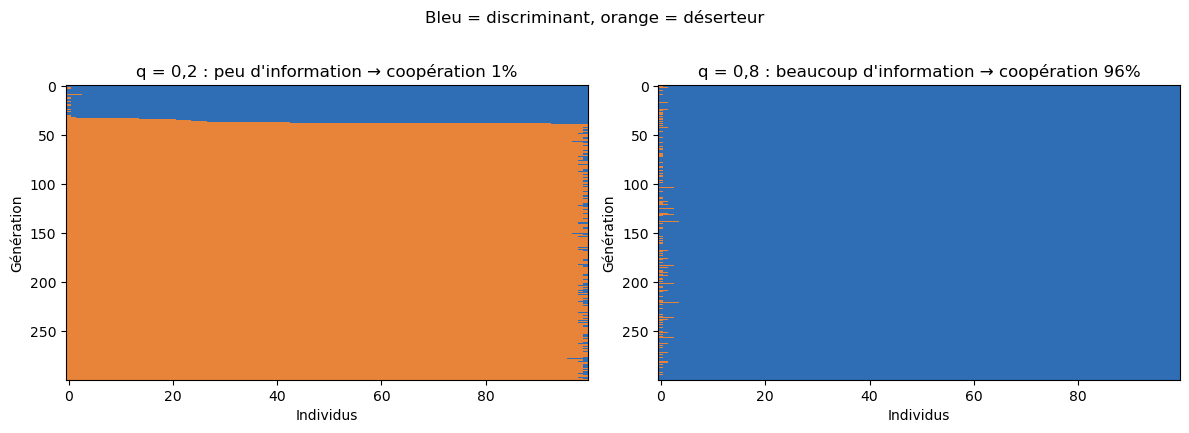

In [6]:
#1. DEUX SIMULATIONS À COMPARER:
hist_bas, coop_bas, _ = simuler(q=0.2)
# village avec PEU d'information : on connaît la réputation de l'autre 1 fois sur 5
# réglages par défaut : que des prudents au départ (100 %), les profiteurs
# n'apparaissent que par mutation → on teste si le village RÉSISTE à leur arrivée

hist_haut, coop_haut, _ = simuler(q=0.8)
# même chose avec BEAUCOUP d'information : 4 fois sur 5
# Le « _ » veut dire : « ce résultat ne m'intéresse pas ici ».
# La fonction renvoie 3 choses (historique, coopération, gain moyen) ;
# on ne garde que les deux premières, le gain moyen est jeté.

#2. LA FIGURE : 2 IMAGES CÔTE À CÔTE:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
# 1 ligne, 2 cases : ax[0] à gauche, ax[1] à droite

#Case gauche : le village avec peu d'information
afficher_population(ax[0], hist_bas, [ALLD, DISC], [ORANGE, BLEU],
                    f"q = 0,2 : peu d'information → coopération {coop_bas[-100:].mean():.0%}")
# [ALLD, DISC] et [ORANGE, BLEU] : profiteurs en orange, prudents en bleu
# le titre calcule tout seul le taux de coopération moyen
# sur les 100 dernières générations (coop_bas[-100:].mean())

#Case droite : le village avec beaucoup d'information:
afficher_population(ax[1], hist_haut, [ALLD, DISC], [ORANGE, BLEU],
                    f"q = 0,8 : beaucoup d'information → coopération {coop_haut[-100:].mean():.0%}")

#Titre commun et affichage:
plt.suptitle("Bleu = discriminant, orange = déserteur", y=1.02)
# suptitle = un titre au-dessus des deux images (la légende des couleurs)
# y=1.02 : placé un peu plus haut pour ne pas chevaucher les titres des cases
plt.tight_layout(); plt.show()     # ajuste les espaces, puis affiche

**Vérification de la règle de Nowak.** Nowak (2006) énonce que la réciprocité indirecte ne favorise la coopération que si **q > c/b**. On fait varier *q* de 0 à 1 pour trois rapports bénéfice/coût, avec 10 simulations par point. Les lignes pointillées indiquent le seuil théorique *c/b*.

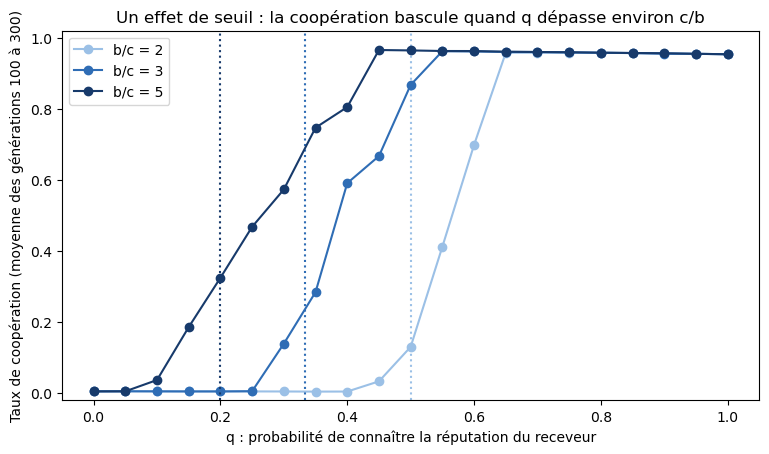

b/c = 2 : seuil théorique c/b = 0.50, seuil observé (coopération > 50 %) ≈ 0.60
b/c = 3 : seuil théorique c/b = 0.33, seuil observé (coopération > 50 %) ≈ 0.40
b/c = 5 : seuil théorique c/b = 0.20, seuil observé (coopération > 50 %) ≈ 0.30


In [7]:
#1. LES VALEURS À TESTER:
valeurs_q = np.linspace(0, 1, 21)
# 21 valeurs de q régulièrement espacées entre 0 et 1 :
# 0 ; 0,05 ; 0,10 ; 0,15 ; … ; 0,95 ; 1

valeurs_b = [2.0, 3.0, 5.0]
# 3 valeurs du bénéfice b (avec c = 1, donc b/c = 2, 3 et 5)
# → 3 seuils théoriques c/b différents : 0,50 ; 0,33 ; 0,20

couleurs_b = ["#9BC0E6", BLEU, "#173A6B"]
# une couleur par valeur de b : bleu clair, bleu, bleu foncé

n_rep = 10
# on répète chaque simulation 10 fois, puis on fait la moyenne
# (une seule simulation pourrait donner un résultat dû au hasard)

#2. LES SIMULATIONS:
resultats = {}          # un « dictionnaire » vide : on y rangera les résultats par valeur de b

for b_ in valeurs_b:    # pour chaque valeur de b (2, puis 3, puis 5)...
    # (on écrit b_ et pas b pour ne pas écraser la variable b définie plus haut)
    resultats[b_] = np.array([[simuler(q, b=b_)[1][100:].mean() for _ in range(n_rep)]
                              for q in valeurs_q])
    # Cette ligne se lit de l'intérieur vers l'extérieur :
    #   simuler(q, b=b_)        → lance une simulation avec ce q et ce b
    #   [1]                     → garde le 2e résultat renvoyé : le taux de coopération
    #                             (0 = historique, 1 = coopération, 2 = gain moyen)
    #   [100:]                  → ignore les 100 premières générations
    #                             (le temps que la population se stabilise)
    #   .mean()                 → moyenne sur les générations 100 à 300
    #   for _ in range(n_rep)   → le tout répété 10 fois
    #   for q in valeurs_q      → pour chacune des 21 valeurs de q
    # Résultat : un tableau de 21 lignes (les q) × 10 colonnes (les répétitions)

# Au total : 3 valeurs de b × 21 valeurs de q × 10 répétitions = 630 simulations

#3. LE GRAPHIQUE:
plt.figure(figsize=(9, 4.8))                    # une figure de taille 9 × 4,8

for b_, col in zip(valeurs_b, couleurs_b):      # zip associe chaque b à sa couleur :
                                                # (2, bleu clair), (3, bleu), (5, bleu foncé)
    m = resultats[b_].mean(axis=1)              # moyenne des 10 répétitions pour chaque q
                                                # (axis=1 : on fait la moyenne sur les colonnes)
    plt.plot(valeurs_q, m, "o-", color=col, label=f"b/c = {b_:.0f}")
    # trace la courbe : q en horizontal, coopération en vertical
    # "o-" = des points reliés par un trait
    plt.axvline(PARAMS["c"] / b_, ls=":", color=col)
    # ligne verticale en pointillés au seuil THÉORIQUE c/b, de la même couleur que la courbe

plt.xlabel("q : probabilité de connaître la réputation du receveur")
plt.ylabel("Taux de coopération (moyenne des générations 100 à 300)")
plt.title("Un effet de seuil : la coopération bascule quand q dépasse environ c/b")
plt.ylim(-0.02, 1.02)   # l'axe vertical va de 0 à 1 (avec une petite marge)
plt.legend()            # affiche la légende (quelle couleur = quel b/c)
plt.show()

#4. COMPARAISON THÉORIE / SIMULATION EN CHIFFRES:
for b_ in valeurs_b:
    m = resultats[b_].mean(axis=1)              # la courbe moyenne pour ce b
    seuil = valeurs_q[np.argmax(m > 0.5)]
    # m > 0.5          → pour chaque q : True si la coopération dépasse 50 %, sinon False
    # np.argmax(...)   → la position du PREMIER True
    # valeurs_q[...]   → la valeur de q correspondante
    # = le plus petit q pour lequel la coopération dépasse 50 % (le « seuil observé »)
    print(f"b/c = {b_:.0f} : seuil théorique c/b = {PARAMS['c']/b_:.2f}, "
          f"seuil observé (coopération > 50 %) ≈ {seuil:.2f}")

**Lecture.** La simulation retrouve qualitativement la règle q > c/b (seuils observés d'environ 0,60, 0,40 et 0,30 pour des seuils théoriques de 0,50, 0,33 et 0,20) : plus l'aide est « rentable » (b/c élevé), moins il faut d'information pour que la coopération tienne. Le seuil observé est un peu au-dessus du seuil théorique. Une explication plausible tient à la présomption de bonne foi : chaque déserteur est aidé « gratuitement » au premier tour de sa vie, avant d'avoir pu montrer qui il est ; les erreurs d'exécution et la dérive aléatoire dans une population de 100 individus jouent aussi.

Surtout, la transition est rapide : sur une plage étroite de q (environ 0,2), la population passe d'une coopération quasi nulle à une coopération quasi totale.

## 5. Résultat 3 — Le tiers de confiance dans une grande société

**Hypothèse.** Par les commérages, un individu connaît la réputation d'environ `K = 40` personnes. Dans une société de taille `S`, la probabilité de connaître la réputation d'un inconnu est donc `q = min(1, K/S)` : plus la société est grande, moins les commérages suffisent.

**Le tiers de confiance.** On ajoute un **registre public** (on peut penser à un casier judiciaire, un registre du commerce, un système de notation) qui rend visible la réputation d'une fraction `π = 50 %` des individus que les commérages ne couvrent pas :

`q = q_commérages + (1 − q_commérages) × π`

Le registre a un coût `f = 2` par individu et par génération, payé par tous, qu'ils coopèrent ou non. Ce coût identique pour tous ne change pas les gains relatifs, donc ne change pas la sélection ; il réduit seulement le bien-être.

On compare le taux de coopération et le **gain moyen net** avec et sans registre, en fonction de la taille de la société.

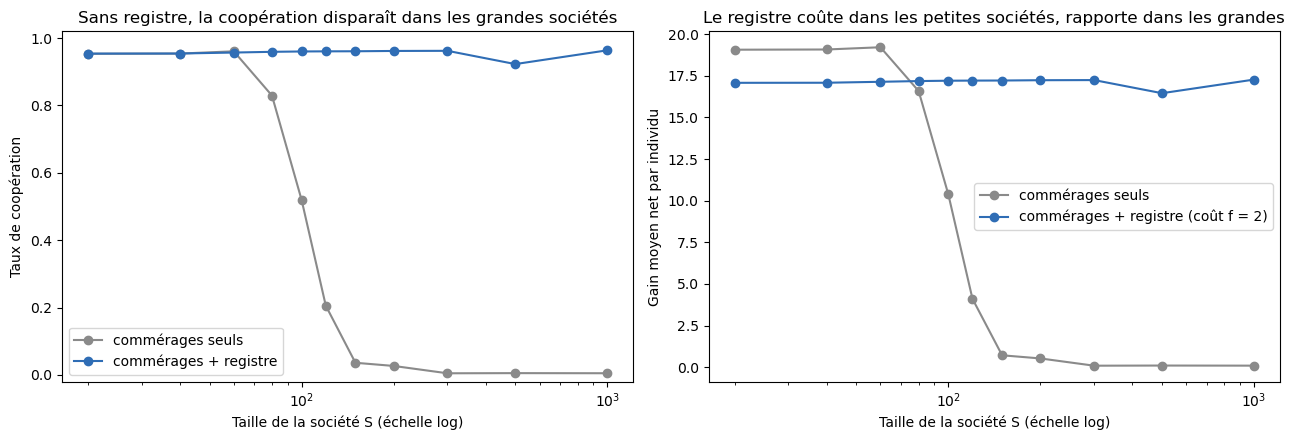

S =    20 : gain net sans registre  19.1, avec registre  17.1
S =    40 : gain net sans registre  19.1, avec registre  17.1
S =    60 : gain net sans registre  19.2, avec registre  17.1
S =    80 : gain net sans registre  16.6, avec registre  17.2   ← registre rentable
S =   100 : gain net sans registre  10.4, avec registre  17.2   ← registre rentable
S =   120 : gain net sans registre   4.1, avec registre  17.2   ← registre rentable
S =   150 : gain net sans registre   0.7, avec registre  17.2   ← registre rentable
S =   200 : gain net sans registre   0.5, avec registre  17.2   ← registre rentable
S =   300 : gain net sans registre   0.1, avec registre  17.2   ← registre rentable
S =   500 : gain net sans registre   0.1, avec registre  16.5   ← registre rentable
S =  1000 : gain net sans registre   0.1, avec registre  17.3   ← registre rentable


In [8]:
#1. LES HYPOTHÈSES:
K, pi, f = 40, 0.5, 2.0
# K  = 40  : grâce aux commérages, on connaît la réputation d'environ 40 personnes
# pi = 0.5 : le registre rend visible la moitié des réputations que les commérages ne couvrent pas
# f  = 2   : coût du registre, payé par chaque individu à chaque génération (un impôt)

tailles = np.array([20, 40, 60, 80, 100, 120, 150, 200, 300, 500, 1000])
# les tailles de société S que l'on teste, d'un petit village (20) à une ville (1000)

#2. LA FONCTION QUI FAIT LES CALCULS:
def resultats_societe(avec_registre):
    # avec_registre = True (il y a un registre) ou False (commérages seuls)
    coop, gain = [], []                    # deux listes vides pour noter les résultats

    for S in tailles:                      # pour chaque taille de société...

        q = min(1.0, K / S)
        # probabilité de connaître la réputation d'un inconnu grâce aux commérages :
        # on connaît 40 personnes sur S. Exemples :
        #   S = 20   → 40/20 = 2, plafonné à 1 (min) : on connaît tout le monde
        #   S = 100  → 40/100 = 0,40
        #   S = 1000 → 40/1000 = 0,04 : on ne connaît presque personne

        if avec_registre:
            q = q + (1 - q) * pi
            # le registre comble la moitié de ce qui manque. Exemples :
            #   S = 100  : 0,40 + (1 − 0,40) × 0,5 = 0,70
            #   S = 1000 : 0,04 + (1 − 0,04) × 0,5 = 0,52
            # → avec le registre, q ne descend jamais sous 0,5, donc reste au-dessus du seuil

        runs = [simuler(q) for _ in range(n_rep)]
        # 10 simulations avec ce q (chacune renvoie historique, coopération, gain moyen)

        coop.append(np.mean([r[1][100:].mean() for r in runs]))
        # r[1] = taux de coopération ; [100:] = générations 100 à 300 ; moyenne des 10 simulations

        gain.append(np.mean([r[2][100:].mean() for r in runs]) - (f if avec_registre else 0))
        # r[2] = gain moyen ; même moyenne que ci-dessus
        # puis on retire le coût f = 2 SEULEMENT s'il y a un registre → c'est le gain NET

    return np.array(coop), np.array(gain)

#3. ON LANCE LES DEUX SCÉNARIOS:
coop_sans, gain_sans = resultats_societe(False)    # commérages seuls
coop_avec, gain_avec = resultats_societe(True)     # commérages + registre
# au total : 2 scénarios × 11 tailles × 10 répétitions = 220 simulations

#4. LA FIGURE : 2 GRAPHIQUES CÔTE À CÔTE:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

#Graphique gauche : le taux de coopération
ax[0].plot(tailles, coop_sans, "o-", color=GRIS, label="commérages seuls")       # courbe grise
ax[0].plot(tailles, coop_avec, "o-", color=BLEU, label="commérages + registre")  # courbe bleue
ax[0].set_xscale("log")
# échelle logarithmique : 10, 100, 1000 sont espacés régulièrement
# (sinon les petites tailles seraient écrasées à gauche du graphique)
ax[0].set_ylim(-0.02, 1.02)
ax[0].set_xlabel("Taille de la société S (échelle log)"); ax[0].set_ylabel("Taux de coopération")
ax[0].set_title("Sans registre, la coopération disparaît dans les grandes sociétés"); ax[0].legend()

#Graphique droit : le gain moyen NET (coût du registre déduit)
ax[1].plot(tailles, gain_sans, "o-", color=GRIS, label="commérages seuls")
ax[1].plot(tailles, gain_avec, "o-", color=BLEU, label=f"commérages + registre (coût f = {f:.0f})")
ax[1].set_xscale("log")
ax[1].set_xlabel("Taille de la société S (échelle log)"); ax[1].set_ylabel("Gain moyen net par individu")
ax[1].set_title("Le registre coûte dans les petites sociétés, rapporte dans les grandes"); ax[1].legend()
plt.tight_layout(); plt.show()

#5. LE TABLEAU EN CHIFFRES:
for S, gs, ga in zip(tailles, gain_sans, gain_avec):
    # zip parcourt les 3 listes en même temps : (taille, gain sans, gain avec)
    print(f"S = {S:5d} : gain net sans registre {gs:5.1f}, avec registre {ga:5.1f}"
          + ("   ← registre rentable" if ga > gs else ""))
    # {S:5d}   = nombre entier aligné sur 5 caractères (pour un tableau bien aligné)
    # {gs:5.1f} = nombre avec 1 décimale
    # on ajoute « ← registre rentable » seulement si le gain avec registre est plus grand

**Lecture.**
- **Petite société** : les commérages suffisent (q élevé). Le registre n'apporte rien et son coût *f* réduit le bien-être.
- **Grande société** (à partir d'environ 80 personnes ici) : les commérages ne suffisent plus, q passe sous le seuil et la coopération s'effondre. Le registre remonte q au-dessus du seuil et **restaure la coopération** : le gain de bien-être dépasse largement son coût.

Grâce à l'effet de seuil, **une institution qui n'apporte qu'une information partielle** (ici la moitié des réputations manquantes) suffit à produire un effet massif sur la coopération. C'est une version très simplifiée de l'idée d'« effet de levier social » : les institutions transforment des incitations de réputation faibles en incitations fortes.

## 6. Discussion, limites et prolongements

**Ce que montre ce pilote.**
1. Sans information sur les réputations, la sélection élimine la coopération, même si elle appauvrit la population.
2. Avec de l'information, la coopération tient au-delà d'un seuil proche de *c/b*, conformément à la règle de Nowak. La transition est rapide.
3. Dans une grande société, un tiers de confiance, même imparfait et coûteux, peut faire repasser la population au-dessus de ce seuil. Son intérêt dépend de la taille de la société.

**Limites.**
- Le registre est ici **exogène** : il existe et il est financé par tous. Dans la réalité, il faut expliquer pourquoi un tel tiers apparaît, qui le paie, et pourquoi il reste honnête. C'est précisément la question des « professionnels de la confiance ».
- La relation `q = K/S` est une hypothèse simplificatrice sur la circulation de l'information.
- Les réputations sont binaires et publiques : tout le monde a le même jugement sur chacun. Des réputations privées, bruitées ou manipulées (fausses rumeurs) rendraient le problème plus difficile.
- Les partenaires sont tirés au hasard : les individus ne **choisissent** pas avec qui interagir.

**Prolongements envisagés.**
- **Choix du partenaire** : laisser les individus refuser un partenaire et en chercher un autre, à un coût. C'est le mécanisme au cœur de l'approche mutualiste de la coopération.
- **Tiers de confiance endogène** : faire évoluer la décision de financer le registre, ou modéliser un intermédiaire rémunéré qui a lui-même une réputation à défendre.
- **Erreurs de réputation** : étudier comment le bruit dans l'information déplace le seuil, et si un tiers de confiance le réduit.

Note : Ce projet a été développé avec l'aide d'une IA, les choix de modélisation et l'interprétation des résultats sont personnels. Ce petit projet s'appuie sur des travaux de recherche existants et n'en propose pas de bibliographie complète : les idées de réciprocité indirecte, de réputation et de rôle des institutions ne sont pas les miennes et reviennent à leurs auteurs.